In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Vivek\Downloads\Affairs.csv")

# Overview

In [4]:
df.head()

,rownames,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,4,0,male,37.0,10.00,no,3,18,7,4
1,5,0,female,27.0,4.00,no,4,14,6,4
2,11,0,female,32.0,15.00,yes,1,12,1,4
3,16,0,male,57.0,15.00,yes,5,18,6,5
4,23,0,male,22.0,0.75,no,2,17,6,3


In [5]:
df.describe(include="all")

,rownames,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
count,601.000000,601.000000,601,601.000000,601.000000,601,601.000000,601.000000,601.000000,601.000000
unique,NaN,NaN,2,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,female,NaN,NaN,yes,NaN,NaN,NaN,NaN
freq,NaN,NaN,315,NaN,NaN,430,NaN,NaN,NaN,NaN
mean,1059.722130,1.455907,NaN,32.487521,8.177696,NaN,3.116473,16.166389,4.194676,3.931780
std,914.904611,3.298758,NaN,9.288762,5.571303,NaN,1.167509,2.402555,1.819443,1.103179
min,4.000000,0.000000,NaN,17.500000,0.125000,NaN,1.000000,9.000000,1.000000,1.000000
25%,528.000000,0.000000,NaN,27.000000,4.000000,NaN,2.000000,14.000000,3.000000,3.000000
50%,1009.000000,0.000000,NaN,32.000000,7.000000,NaN,3.000000,16.000000,5.000000,4.000000
75%,1453.000000,0.000000,NaN,37.000000,15.000000,NaN,4.000000,18.000000,6.000000,5.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rownames       601 non-null    int64  
 1   affairs        601 non-null    int64  
 2   gender         601 non-null    str    
 3   age            601 non-null    float64
 4   yearsmarried   601 non-null    float64
 5   children       601 non-null    str    
 6   religiousness  601 non-null    int64  
 7   education      601 non-null    int64  
 8   occupation     601 non-null    int64  
 9   rating         601 non-null    int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 47.1 KB


## Insights
##### age - normal distribution
##### religiousness, education, occupation, rating - one hot encoded
##### occupation and education - Holingshead classification (reverse numbering)

# Distruibution

In [7]:
df.columns

Index(['rownames', 'affairs', 'gender', 'age', 'yearsmarried', 'children',
       'religiousness', 'education', 'occupation', 'rating'],
      dtype='str')

In [8]:
quant = ['affairs','age','yearsmarried']
categ = ['gender','children','religiousness','education','occupation','rating']

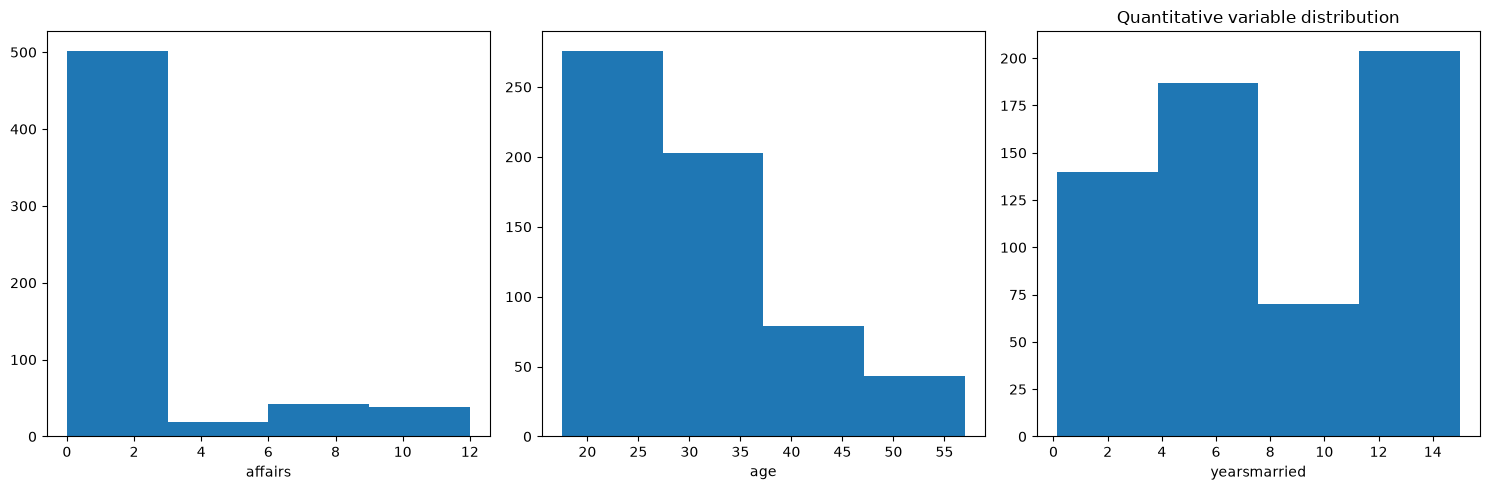

In [18]:
fig, ax = plt.subplots(1,3,figsize = (15,5))
for i in range(len(quant)):
    ax[i].hist(df[quant[i]],bins = 4)
    ax[i].set_xlabel(quant[i])
plt.title("Quantitative variable distribution")
plt.tight_layout()

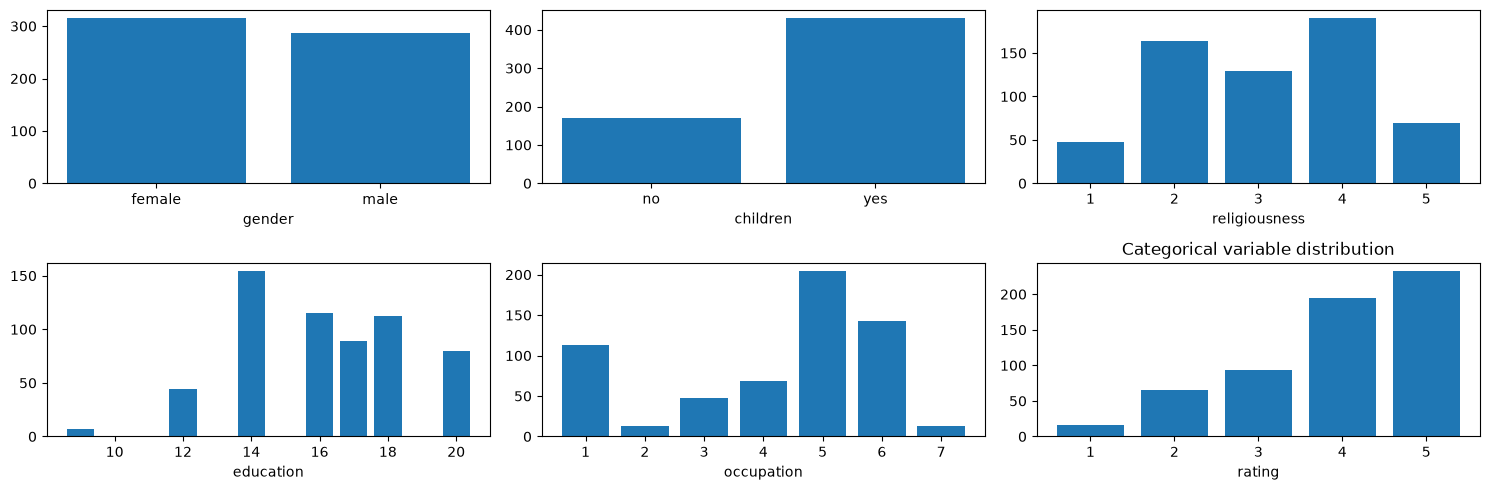

In [21]:
fig, ax = plt.subplots(2,3,figsize = (15,5))
cat = iter(categ)
def group(col):
    x = df.groupby(col)[col].count()
    return x
for i in range(2):
    for j in range(3):
        col = next(cat)
        y = group(col)
        ax[i][j].bar(y.index, y)
        ax[i][j].set_xlabel(col)
plt.title("Categorical variable distribution")
plt.tight_layout()

# rating wise average, max, min affairs count
# iike wise we can do for each categorical variable wise